In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/puneet6060
/kaggle/input/datasets/puneet6060/intel-image-classification
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/street
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/buildings
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/sea
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/forest
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/glacier
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred
/kaggle/input/datasets/puneet6060/in

# Week 4: Deep Learning with PyTorch

## Setup

In [5]:
import os
os.makedirs("outputs", exist_ok=True)

import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
from pathlib import Path

# The standard device check — you'll use this pattern in every PyTorch notebook
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version:     {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version:     2.10.0+cu128
TorchVision version: 0.25.0+cu128


## PyTorch Tensors

### Question 1
Create tensors and inspect their properties.

In [6]:
a = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])

b = torch.zeros(2, 3)
c = torch.ones(4)

def describe_tensor(name, t):
    print(f"{name}:")
    print(t)
    print(f"shape:  {t.shape}")
    print(f"dtype:  {t.dtype}")
    print(f"device: {t.device}")
    print()

describe_tensor("a", a)
describe_tensor("b", b)
describe_tensor("c", c)

a:
tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape:  torch.Size([2, 3])
dtype:  torch.float32
device: cpu

b:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
shape:  torch.Size([2, 3])
dtype:  torch.float32
device: cpu

c:
tensor([1., 1., 1., 1.])
shape:  torch.Size([4])
dtype:  torch.float32
device: cpu



**Answer:**

All tensors are currently on the CPU, as shown by the device value.

If we were training a model on a GPU, both the model and the input tensors must be on the same device (either CPU or GPU). Otherwise, PyTorch will raise an error.

Keeping tensors and model on the GPU allows faster parallel computation during training.

### Question 2

Starting from a tensor of numbers, compute the square root, sum, mean, and index of the maximum value.

In [7]:
# Create a 1D tensor (vector)
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

# Element-wise square root (applies sqrt to each element)
sqrt_x = torch.sqrt(x)

# Aggregate operations
sum_x = x.sum()
mean_x = x.mean()

# argmax returns the INDEX of the largest value (not the value itself)
max_index = x.argmax()

print("x:")
print(x)

print("\nElement-wise square root:")
print(sqrt_x)

print("\nSum:")
print(sum_x)

print("\nMean:")
print(mean_x)

print("\nIndex of maximum value:")
print(max_index)

x:
tensor([ 1.,  4.,  9., 16., 25.])

Element-wise square root:
tensor([1., 2., 3., 4., 5.])

Sum:
tensor(55.)

Mean:
tensor(11.)

Index of maximum value:
tensor(4)


**Answer:**

The square root is applied element-wise, meaning each value in the tensor is transformed independently.

The sum and mean operations aggregate all elements into a single value.

The argmax function returns the index of the maximum value, not the value itself. In this case, the largest value is 25.0, which is located at index 4.

### Question 3

Move tensor `a` to the selected device, move it back to CPU, and convert it to a NumPy array.

In [8]:
# Move tensor a to the selected device (GPU if available, otherwise CPU)
a_gpu = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

# NumPy works with CPU memory, so we move the tensor back to CPU first
a_back = a_gpu.cpu()
a_numpy = a_back.numpy()

print(f"numpy type: {type(a_numpy)}")
print(f"numpy values:\n{a_numpy}")

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values:
[[1. 2. 3.]
 [4. 5. 6.]]


**Answer:**

The tensor was successfully moved to the GPU, as shown by the device value `cuda:0`.

Before converting the tensor to a NumPy array, it had to be moved back to the CPU using `.cpu()`, because NumPy arrays can only exist in CPU memory.

This shows that PyTorch tensors can live on different devices (CPU or GPU), while NumPy arrays are limited to CPU.

Pipline: Data (CPU) → Tensor → GPU → model → GPU → CPU → NumPy → output

### Question 4

Reshape tensors and manipulate dimensions.

In [9]:
# Create a tensor with values from 0 to 23
t = torch.arange(24).float()

print("Original tensor:")
print(t)
print("shape:", t.shape)

# Step 1: reshape to (4, 6)
t_2d = t.view(4, 6)
print("\nReshaped to (4, 6):")
print(t_2d)
print("shape:", t_2d.shape)

# Step 2: reshape to (2, 3, 4)
t_3d = t.view(2, 3, 4)
print("\nReshaped to (2, 3, 4):")
print(t_3d)
print("shape:", t_3d.shape)

# Step 3: add a new dimension at position 0 (batch dimension)
t_batch = t_2d.unsqueeze(0)
print("\nAfter adding batch dimension:")
print(t_batch)
print("shape:", t_batch.shape)

Original tensor:
tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20., 21., 22., 23.])
shape: torch.Size([24])

Reshaped to (4, 6):
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.],
        [ 6.,  7.,  8.,  9., 10., 11.],
        [12., 13., 14., 15., 16., 17.],
        [18., 19., 20., 21., 22., 23.]])
shape: torch.Size([4, 6])

Reshaped to (2, 3, 4):
tensor([[[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]],

        [[12., 13., 14., 15.],
         [16., 17., 18., 19.],
         [20., 21., 22., 23.]]])
shape: torch.Size([2, 3, 4])

After adding batch dimension:
tensor([[[ 0.,  1.,  2.,  3.,  4.,  5.],
         [ 6.,  7.,  8.,  9., 10., 11.],
         [12., 13., 14., 15., 16., 17.],
         [18., 19., 20., 21., 22., 23.]]])
shape: torch.Size([1, 4, 6])


**Answer:**

The tensor was reshaped into different dimensions without changing its data.

First, it was reshaped from a 1D tensor of shape [24] into a 2D tensor of shape [4, 6], and then into a 3D tensor of shape [2, 3, 4].

Finally, a new dimension was added at position 0 using `unsqueeze(0)`, resulting in a shape of [1, 4, 6].

This operation is important because neural networks expect input data in batches. Even when processing a single sample, we need to add a batch dimension so that the input has the correct shape.

### Question 5

Compare matrix multiplication in NumPy and PyTorch.

In [10]:
import numpy as np

# NumPy arrays
np_a = np.array([[1.0, 2.0], 
                 [3.0, 4.0]])

np_b = np.array([[5.0, 6.0], 
                 [7.0, 8.0]])

# PyTorch tensors
t_a = torch.tensor(np_a, dtype=torch.float32)
t_b = torch.tensor(np_b, dtype=torch.float32)

# Matrix multiplication in NumPy
np_result = np.matmul(np_a, np_b)

# Matrix multiplication in PyTorch
torch_result = torch.matmul(t_a, t_b)

print("NumPy result:")
print(np_result)

print("\nPyTorch result:")
print(torch_result)

NumPy result:
[[19. 22.]
 [43. 50.]]

PyTorch result:
tensor([[19., 22.],
        [43., 50.]])


**Answer:**

The results of matrix multiplication in NumPy and PyTorch are the same, which confirms that both libraries perform the same mathematical operation.

Matrix multiplication is a core operation in neural networks. At a high level, each layer in a neural network computes a weighted sum of inputs using matrix multiplication.

This allows the model to transform input data into more complex representations as it passes through each layer.

output = input × weights + bias

## Pretrained Models

### Question 1

Load a pretrained ResNet18 model and count its parameters.

In [11]:
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 230MB/s]

Total parameters:     11,689,512
Trainable parameters: 11,689,512


**Answer:**

ResNet18 has approximately 11.7 million parameters, all of which are trainable.

Training a model with this many parameters from scratch would require a very large dataset and significant computational resources. This demonstrates the practical value of using pretrained models.

By starting with pretrained weights, we can leverage knowledge learned from large datasets like ImageNet and adapt the model to new tasks with much less data and time.

Transfer Learning (not from 0)

### Question 2

Inspect the architecture of ResNet18 and identify key components.

In [12]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

**Answer:**

The final layer of ResNet18 is called `fc` (fully connected layer), and it has an output size of 1000.

This means the model produces predictions for 1000 different classes from the ImageNet dataset.

The layers named `layer1` through `layer4` represent the deeper parts of the network (the main brain of the model), where more complex features are learned. A "deep" network means it has many layers that progressively extract higher-level features from the input data.

### Question 3

Move the model to the correct device and set it to evaluation mode.

In [13]:
# Move model to GPU (if available)
model = model.to(device)

# Set model to evaluation mode
model.eval()

print("Model ready for inference.")

Model ready for inference.


**Answer:**

The model was moved to the selected device using `.to(device)` so that it matches the device of the input tensors.

The `model.eval()` method switches the model to evaluation mode, which changes the behavior of certain layers such as Dropout and BatchNorm.

For example, Dropout is disabled during evaluation, and BatchNorm uses learned statistics instead of updating them. This ensures consistent and reliable predictions during inference.

Difference between model.train() and model.eval():

model.train() is used during training and enables layers like Dropout and BatchNorm to update their behavior.

model.eval() is used during inference and disables randomness, ensuring consistent predictions.

### Question 4

Inspect the preprocessing pipeline used by the pretrained model.

In [14]:
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


**Answer:**

The preprocessing pipeline resizes the image to a standard size and then crops it to 224×224 pixels, which matches the input size expected by the model.

The image is then converted into a tensor, where pixel values are scaled to a range suitable for neural networks.

Normalization adjusts the pixel values using the mean and standard deviation from the ImageNet dataset. This ensures that the input data has a similar distribution to the data the model was trained on, which improves prediction accuracy.

Without normalization model thinks: "This is different data".

## Running Inference

### Question 1

Run inference on a single image and return the top-5 predictions.

In [15]:
# Helper setup for inference

import random
random.seed(42)

DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    """Load a random image file from the given class folder."""
    class_dir = DATA_DIR / label
    img_path = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")




Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


In [16]:
import torch.nn.functional as F

def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top-5 predictions.
    Returns a list of (class_name, probability) tuples.
    """

    # Step 1: preprocess + add batch dimension
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    # Step 2: inference (no gradients needed)
    with torch.no_grad():
        output = model(input_tensor)

    # Step 3: convert logits to probabilities
    probs = F.softmax(output[0], dim=0)

    # Step 4: top 5
    top_probs, top_indices = torch.topk(probs, 5)

    # Step 5: map to class names
    results = [
        (class_labels[idx], prob.item())
        for idx, prob in zip(top_indices, top_probs)
    ]

    return results

In [17]:
img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}':")
for class_name, prob in preds:
    print(f"{class_name:30s} {prob:.4f}")


Top-5 predictions for '24204.jpg':
alp                            0.4911
volcano                        0.2076
valley                         0.2016
promontory                     0.0184
mountain tent                  0.0169


**Answer:**

The top prediction is `alp` with a probability of 0.4911, which makes sense for a mountain image.

Other high-ranking predictions such as `volcano` and `valley` also relate to mountain or landscape scenes.

The model was trained on ImageNet categories, so it does not simply predict the broad label "mountain." Instead, it predicts one of ImageNet's specific classes, such as `alp`, `valley`, or `promontory`.

### Question 2

Run inference on images from all classes and compare the predictions.

In [18]:

for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]

    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"{class_name:30s}  {prob:.4f}")


[buildings]  24258.jpg
palace                          0.4301
gondola                         0.1305
monastery                       0.0624

[forest]  23309.jpg
viaduct                         0.3853
totem pole                      0.1089
cliff                           0.0419

[glacier]  20272.jpg
volcano                         0.3854
valley                          0.3297
promontory                      0.1216

[mountain]  20662.jpg
ski                             0.5933
alp                             0.3821
snowmobile                      0.0071

[sea]  23069.jpg
seashore                        0.2016
breakwater                      0.1834
geyser                          0.1718

[street]  24269.jpg
unicycle                        0.1299
triumphal arch                  0.1268
jinrikisha                      0.1049


**Answer:**

The model shows varying levels of confidence across different image classes.

It appears more confident in some cases, such as "mountain," where the top predictions like "ski" and "alp" are closely related to the scene.

However, for other categories like "forest" and "street," the model produces less accurate or less relevant predictions, such as "viaduct" or "unicycle," and with lower confidence scores.

This pattern suggests that the model performs better when the image closely matches the types of scenes it was trained on in ImageNet, and struggles when the categories differ or are more abstract.

### Question 3

Compare logits and probabilities produced by the model.

In [19]:
img, _ = load_sample_image("forest")

input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit range: min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob range:  min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")

top_idx = probs.argmax().item()
print(f"Top prediction: {imagenet_classes[top_idx]} ({probs.max():.4f})")

Logit range: min=-4.87, max=6.61
Prob range:  min=0.000001, max=0.0979
Probs sum to: 1.000000
Top prediction: mountain bike (0.0979)


**Answer:**

The logits are the raw outputs of the model and can take any real values, as shown by the wide range from -4.87 to 6.61.

After applying softmax, the values are converted into probabilities between 0 and 1 that sum to 1. This makes them easier to interpret.

Neural networks use logits internally because they are more numerically stable during training. In practice, probabilities are used when we need interpretable outputs, such as selecting the most likely class or filtering predictions by confidence.

Why not apply softmax inside the model?

Because many loss functions (like CrossEntropyLoss) expect raw logits for numerical stability.

### Question 4

Visualize an image and its top-5 predictions.

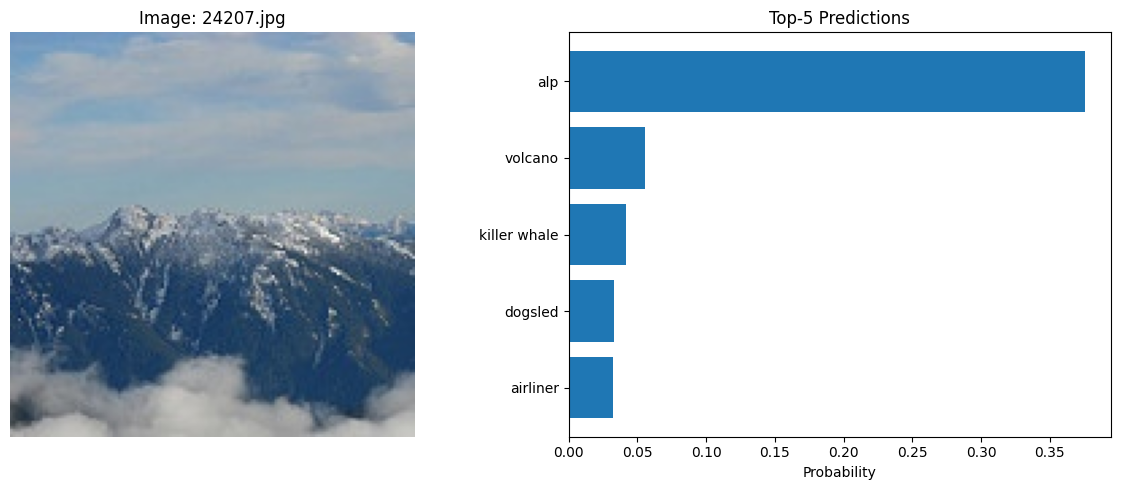

In [20]:
# Load image
img, img_name = load_sample_image("mountain")

# Get predictions
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

# Separate labels and probabilities
class_names = [p[0] for p in preds]
probs = [p[1] for p in preds]

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: image
axes[0].imshow(img)
axes[0].set_title(f"Image: {img_name}")
axes[0].axis("off")

# Right: bar chart
axes[1].barh(class_names[::-1], probs[::-1])
axes[1].set_title("Top-5 Predictions")
axes[1].set_xlabel("Probability")

plt.tight_layout()

# Save figure
plt.savefig("outputs/warmup_inference_viz.png")

plt.show()

In [21]:
import os
print(os.listdir("outputs"))

['warmup_inference_viz.png']


**Answer:**

This visualization shows the input image together with the model's top-5 predictions.

The model correctly identifies the image as related to mountains, with `alp` as the top prediction. The bar chart makes it easier to compare the model's confidence across the predicted classes.

For a dashboard used by non-technical users, I would show the image, the top prediction, and a confidence score. I would also flag predictions with low confidence, for example below 0.5, for manual review.